## Objective : Predict  whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight or delivery patterns in order to reduce finacial risk, improve operational efficiency and prioritize human review where it adds the most value.
- manual invoice review is time-consuming and does not scale with transaction volume.
- Abnormal freight chrges,pricing deviations or delivery delays often indicate errors, disputes or compliance risks.
- An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [1]:
import sqlite3
import pandas as pd  
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("../data/inventory.db")

In [3]:
tables = pd.read_sql_query("Select name from sqlite_master where type='table'",conn)
for t in tables['name']:
    print(f"Table name: {t}")
    display(pd.read_sql(f"select * from {t} limit 5",conn))    

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [5]:
purchase_agg_df = pd.read_sql_query("""
select 
PONumber,
count(distinct Brand) as total_brands, 
sum(Quantity) as total_item_quantity, 
sum(Dollars) as total_item_dollars, 
avg(julianday(ReceivingDate) - julianday(PODate)) as average_receiving_delay
from purchases 
group by PONumber
""",conn)

In [8]:
pd.read_sql_query("""
select
PONumber,
Quantity as invoice_quantity, 
Dollars as invoice_dollars, 
Freight, 
(julianday(InvoiceDate) - julianday(PODate)) as days_po_to_invoice, 
(julianday(PayDate) - julianday(InvoiceDate)) as days_to_pay
from vendor_invoice
""",conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [10]:
df = pd.read_sql_query("""
with purchase_agg AS(
    select 
    p.PONumber,
    count(distinct p.Brand) as total_brands, 
    sum(p.Quantity) as total_item_quantity, 
    sum(p.Dollars) as total_item_dollars, 
    avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as average_receiving_delay
    from purchases as p 
    group by p.PONumber
)

select 
    vi.PONumber,
    vi.Quantity as invoice_quantity, 
    vi.Dollars as invoice_dollars, 
    vi.Freight, 
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice, 
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay, 
    pa.total_brands, 
    pa.total_item_quantity, 
    pa.total_item_dollars,
    pa.average_receiving_delay    
from vendor_invoice as vi
left join purchase_agg as pa 
ON vi.PONumber = pa.PONumber
""",conn)

In [11]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,average_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [12]:
df.isnull().sum()

PONumber                   0
invoice_quantity           0
invoice_dollars            0
Freight                    0
days_po_to_invoice         0
days_to_pay                0
total_brands               0
total_item_quantity        0
total_item_dollars         0
average_receiving_delay    0
dtype: int64

In [13]:
def create_inoice_risk_label(row):
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1
    if row["average_receiving_delay"] > 10: 
        return 1
    return 0

df["flag_invoice"] = df.apply(create_inoice_risk_label , axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

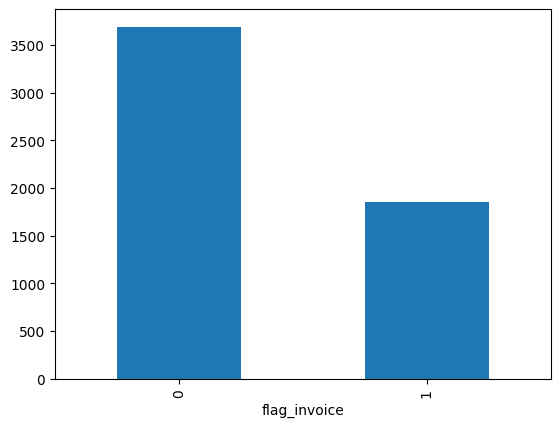

In [16]:
df["flag_invoice"].value_counts().plot(kind ="bar")

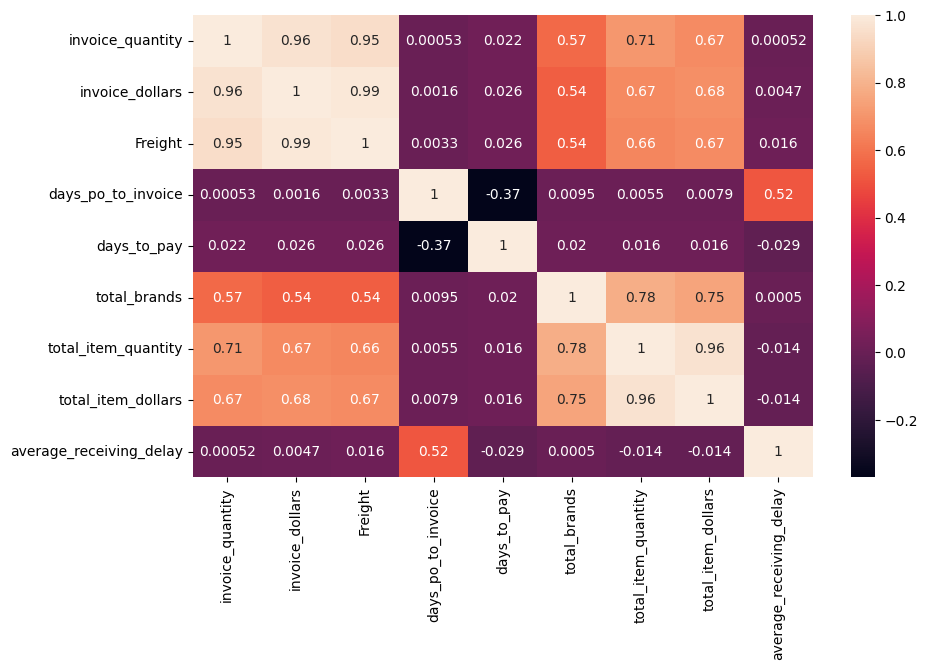

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.iloc[:,1:-1].corr() , annot=True)
plt.show()

In [21]:
flagged = df[df['flag_invoice']==1]
normal = df[df['flag_invoice']==0]

In [22]:
significant_features = [] 
non_significant_features = []  
results = []

In [25]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight','days_po_to_invoice', 'days_to_pay', 'total_brands','total_item_quantity', 'total_item_dollars', 'average_receiving_delay']

In [28]:
from scipy.stats import ttest_ind
for m in metrics:
    flagged_mean = flagged[m].mean()
    normal_mean = normal[m].mean()

    t_stat , p_value = ttest_ind(
        flagged[m].dropna(), 
        normal[m].dropna(),
        equal_var = False
    )

    if p_value < 0.05:
        significant_features.append(m)
        results.append({
            "metric":m, 
            "flagged_mean" : flagged_mean.round(2), 
            "normal_mean" : normal_mean.round(2), 
            "p_value" : p_value.round(3)
        })
    else: 
        non_significant_features.append(m)

In [29]:
non_significant_features

['days_to_pay', 'total_brands']

In [30]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'average_receiving_delay']

In [33]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight','days_po_to_invoice','total_item_quantity', 'total_item_dollars', 'average_receiving_delay']]
y = df['flag_invoice']

In [34]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_item_quantity,total_item_dollars,average_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,3.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,9.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,14.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,16.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,19.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,23.0,141660.0,1660436.0,13.0


In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [40]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled,y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled,y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Logistic Regression
Accuracy: 0.739404869251578
              precision    recall  f1-score   support

           0       0.74      0.93      0.82       725
           1       0.74      0.38      0.50       384

    accuracy                           0.74      1109
   macro avg       0.74      0.66      0.66      1109
weighted avg       0.74      0.74      0.71      1109


Decision Tree Classifier
Accuracy: 0.9486023444544635
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       725
           1       0.95      0.90      0.92       384

    accuracy                           0.95      1109
   macro avg       0.95      0.94      0.94      1109
weighted avg       0.95      0.95      0.95      1109


Random Forest Classifier
Accuracy: 0.9558160504959423
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       725
           1       1.00      0.87      0.93       384

    accuracy           

In [48]:
model3.feature_importances_

array([0.10668727, 0.10055568, 0.10323929, 0.02603186, 0.15331893,
       0.20578767, 0.3043793 ])

In [49]:
feature_importance = pd.DataFrame({
    "feature" : X_train.columns, 
    "importance": model3.feature_importances_
}).sort_values(by="importance" , ascending = False)

feature_importance

,feature,importance
6,average_receiving_delay,0.304379
5,total_item_dollars,0.205788
4,total_item_quantity,0.153319
0,invoice_quantity,0.106687
2,Freight,0.103239
1,invoice_dollars,0.100556
3,days_po_to_invoice,0.026032


In [50]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight','total_item_quantity', 'total_item_dollars']]
y = df['flag_invoice']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

In [52]:
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)

evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Random Forest Classifier
Accuracy: 0.8845807033363391
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
           1       0.94      0.72      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109



In [54]:
from sklearn.metrics import make_scorer , f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42,n_jobs=1)
param_grid = {
    "n_estimators" : [100, 200, 300],
    "max_depth" : [None, 4, 5, 6], 
    "min_samples_split" : [2,3,5], 
    "min_samples_leaf" : [1,2,5], 
    "criterion" : ['gini', 'entropy']
}
scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf, param_grid=param_grid, scoring=scorer, cv=5, verbose=2, n_jobs=-1
)
grid_search.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...], ...}"
,scoring,make_scorer(f...hod='predict')
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [59]:
evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classifier')


Model: Random Forest Classifier
Accuracy: 0.8881875563570785
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       725
           1       0.96      0.71      0.81       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.88      1109



In [63]:
from sklearn.metrics import confusion_matrix 

confusion_matrix(grid_search.predict(X_test_scaled),y_test)

array([[713, 112],
       [ 12, 272]])

In [62]:
confusion_matrix(model3.predict(X_test_scaled),y_test)

array([[706, 109],
       [ 19, 275]])

In [65]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}